# 第1课 · 拒绝黑盒——Aurora 的动机、路线图与环境自检

**本课先做什么（先看这一句）**：不是把 Whisper 一口气写完，而是先把三件事站稳——**为什么要从零做**、**6 个月要去哪里**、**环境能不能跑起来**。正弦波只是开场的「第一声」，先让你摸到“声音进电脑”大概长什么样。

**学习目标**
1. 理解 Aurora 为什么要从零实现，而不是调用现成 API
2. 看到完整的 11 模块路线图和每月通关标志
3. 用「我学 X 是为了能做 Y」的句式内化每个模块的意义
4. 实现 `check_imports` 和 `environment_report`——主动调试你的开发环境
5. 写下 3 个 6 个月后可以回头验收的个人目标

### ⏱ 本课 30 分钟「最小路径」（时间紧时按这条走）

后面章节信息很多，像一张展开的总地图。若你只想先「站稳再开课」，按下面顺序即可，其余先收进地图，随时回来翻：

1. 读 **§1 为什么从零写** + **三把钥匙**，跑通正弦波那一格（建立画面）
2. 扫一眼 **§2 原则**、**§3 四个系统**、**§4 路线图**（知道去哪，不必背）
3. 做 **§6 模块意义** 里你现在写得出的几条 + **§11 三个个人目标**
4. 实现 **`check_imports`** 与 **`environment_report`**，跑通冒烟测试

§5 通关表、§7 面试追问表、§8 快捷键：先当作「预告片 / 工具卡」，第一天不要求全懂。


← **起点课**　无上一课

> 本课先把 Aurora 的动机、路线图与环境自检工具搭起来。
> 下一课进入 **采样与第一声可听正弦波（sine wave）**（L02）——把这里「看过一眼」的采样率，变成你亲手写的四个小函数。


## 1. 为什么从零写？

你只要两行代码，就能把 Whisper 当黑盒调用：

```python
import openai
openai.audio.transcriptions.create(model="whisper-1", file=audio_file)
```

但这并不代表你真懂。当有人（面试、同事，或未来的自己）追问时，你要答得上来：

| 别人会追问的问题 | 你答得上吗？ |
|---|---|
| Whisper 的 Mel filterbank 用多少个三角滤波器？为什么是 80？ | ❌ 用了 API 就不知道 |
| FFT 的时间复杂度为什么是 O(N log N)？蝶形网络（butterfly network）是什么？ | ❌ |
| CTC loss 如何处理未知对齐？forward-backward 算法是什么？ | ❌ |

**补一句边界**：就算你把上面的 OpenAI 换成本机 `pipeline` 或本地推理脚本，只要核心算法还是别人写好的黑盒，面试时被追问「为什么 / 怎么算」，你照样会卡住。黑盒不看品牌名，只看你能不能从空白文件推出来。

Aurora 的方法：**自己写每一层**，然后用参考实现对答案。
6 个月后，上面三个问题都能在白板上推导。


### 读第一段代码前：三把钥匙（现在看不懂公式完全正常）

下面这 5 行代码是本课唯一需要你先动手跑通的"真代码"。**你现在的任务只是把它跑出来、先看图感受**——
采样的原理 L02 会逐行拆解，sin 和 2π 是 L04 的主角。这里先给你三把钥匙，
不需要全部想通，先读出"每行在干什么"就够了。

**钥匙 1：`sr = 16000`（采样率）——每秒拍 16000 张"快照"**

声音是连续变化的，电脑却只能记一串离散数字，所以只能每隔一小段时间拍一张快照，
就像用连拍记录一段舞蹈。每秒记录的次数就叫**采样率**（sample rate）。
`sr = 16000` 表示每秒记 16000 个数。（为什么是 16000、多快才够快，L02 详讲。）

**钥匙 2：`t = np.arange(round(duration * sr)) / sr`——先编号，再换算成秒**

这一行可以拆成两步看：
1. `np.arange(round(0.02 * 16000))` → 生成整数编号 `0, 1, 2, ..., 319`。
   0.02 秒 × 每秒 16000 个点 = 一共 320 个点，所以编号到 319。
2. `/ sr` → 把"第几个点"换算成"第几秒"：第 n 个点发生在 n/16000 秒。
   于是 `t` 就是一串均匀的时刻：0 秒、1/16000 秒、2/16000 秒……

**钥匙 3：`np.sin(2 * np.pi * freq * t)`——2π 是"转一整圈"**

高中更常先见到**角度制**（比如 $\sin 30° = 0.5$）；弧度也学过，只是很多人平时不常用。
而 `np.sin` 吃的是另一种角度单位——**弧度**（radian）：转一整圈 = $360°$ = $2\pi$ 弧度（约 6.28）。

想象一个点绕圆匀速转圈，sin 值就是它离地的高度。转一圈，高度刚好起伏一个来回，
这就是一个完整的波。现在读公式：
- `freq * t` = "到时刻 t 为止，一共转了几圈"（每秒转 freq = 440 圈）；
- 乘上 `2 * np.pi` = 把"圈数"换算成 np.sin 认识的"弧度数"。

所以 $\sin(2\pi \cdot 440 \cdot t)$ 读作：**一个每秒转 440 圈的点的高度随时间的变化**——这就是 440 Hz 的声音。

顺带一提：**A4 音**就是钢琴中央区那个标准音 A（La），乐队调音用的就是它，频率 440 Hz。

> 先把这三把钥匙收好，L02 和 L04 会把它们一把一把拆开、重讲一遍。现在跑下面的代码，看图。


In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


shape=(320,)  dtype=float64  范围=[-1.00, 1.00]


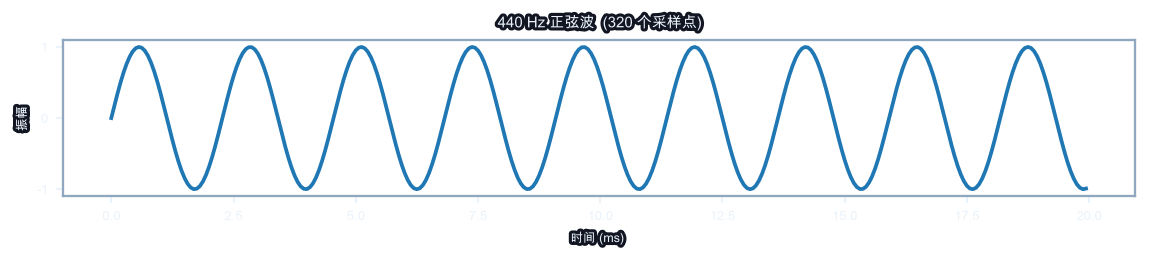

In [2]:
# 你能在 5 行 NumPy 里造出 Whisper 最底层所需的正弦波
import numpy as np
import matplotlib.pyplot as plt

sr, duration, freq = 16000, 0.02, 440  # 采样率, 时长(秒), A4 音
t = np.arange(round(duration * sr)) / sr
x = np.sin(2 * np.pi * freq * t)  # aurora.audio.sine 的核心就是这一行

plt.figure(figsize=(8, 2))
plt.plot(t * 1000, x)
plt.xlabel('时间 (ms)'); plt.ylabel('振幅')
plt.title(f'440 Hz 正弦波  ({len(t)} 个采样点)')
plt.tight_layout(); plt.show()
print(f'shape={x.shape}  dtype={x.dtype}  范围=[{x.min():.2f}, {x.max():.2f}]')

In [3]:
# 三把钥匙的现场验证——用打印代替"先信了"
# （直接使用上一格已算好的 t、x）

# 钥匙 2 的验证：t 到底长什么样？
print('t 的前 5 个元素:', t[:5])
print(f'相邻两个时刻的间隔: {t[1] - t[0]:.10f} 秒  （正好是 1/sr = 1/{sr}）')
print(f'点的总数: {len(t)} 个  （= 时长 × 采样率 = {duration} × {sr}）')

# 钥匙 3 的验证：0.02 秒里应该装下多少个完整的波？
print(f'\n理论上的完整波数: freq × duration = {freq} × {duration} = {freq * duration:.1f} 个')
peaks = np.sum((x[1:-1] > x[:-2]) & (x[1:-1] > x[2:]))
print(f'从数组里实际数出的波峰个数: {peaks} 个  ——和理论值 ≈8.8 对上了（回头再看看上面的图）')

t 的前 5 个元素: [0.000e+00 6.250e-05 1.250e-04 1.875e-04 2.500e-04]
相邻两个时刻的间隔: 0.0000625000 秒  （正好是 1/sr = 1/16000）
点的总数: 320 个  （= 时长 × 采样率 = 0.02 × 16000）

理论上的完整波数: freq × duration = 440 × 0.02 = 8.8 个
从数组里实际数出的波峰个数: 9 个  ——和理论值 ≈8.8 对上了（回头再看看上面的图）


## 2. Aurora 的核心原则

> **当实现一个核心能力时，构建算法本身——不导入已经完成的黑盒。**

具体边界：

| 模块 | 允许 | 禁止 |
|---|---|---|
| audio_core | NumPy（数组容器 + 逐元素运算）| librosa、scipy.signal |
| deep_learning | PyTorch 自动微分（automatic differentiation，autograd） | `torch.nn` 当算法捷径 |
| ASR / Music | HuggingFace（推理框架）| Whisper API 当「我理解了 ASR」|
| LLM | HuggingFace transformers | ChatGPT API 当「我实现了 LLM」|

这条原则不是仪式——它是你能向任何人（也向自己）讲清楚的那条边界。

## 3. 你将构建什么

常见的**假目标**（容易误判的 KPI）：10000 个 commit、博客 20 篇、会用 10 个框架——
数字好看，却往往说不清「你到底懂哪一层」。
真正的目标：**少量、正确、能向任何人讲清楚的深度作品**——做出的是你真懂的作品与思路，不是作品集数量。

6 个月，4 个可展示的**终局系统**（整台机器长什么样）：

```
① Audio Analysis Engine
   FFT + STFT + Mel filterbank + MFCC，全部手写，39 个测试全绿

② Keyword Spotting (KWS) Demo
   CNN 分类器，从波形到 yes/no，PyTorch 训练

③ ASR Transcript Engine
   CTC loss 手写，Whisper 架构理解，WER 评估

④ Podcast Intelligence (RAG + QA)
   TF-IDF 检索，RAG 流水线，Tool-calling Agent
```

每个系统都有：跑通的 demo、技术 blog 一篇、能随时现场推导的核心算法。

> **和下一节「每月通关」怎么对上？**  
> 这里的 ①–④ 是**终点作品**；§5 的 Month 1–6 是**按月拆开的里程碑**。  
> 例如 Month 4 的交付物写「LM Core」，指的是先把语言模型（Transformer / fine-tune）地基打牢；  
> Month 5 再把检索与问答拼进 ④ Podcast Intelligence。  
> 所以：**不是「第四个系统改名叫 LM 了」**，而是「做 ④ 之前，先过 Month 4 这块砖」。


## 4. 课程路线图（11 模块）

> **读图小提示**：括号里的英文是术语「身份证」，第一遍先看中文含义就够了；  
> 本课先会碰到 FFT、Whisper 这类少数缩写，其余英文会在对应模块开篇再立。

```
L01–L05  ① 开场          动机、声音表示、谱图直觉、三角函数、复数（complex number）
              ↓
L06–L08  ② Fourier 直觉  欧拉公式（Euler's formula） → Fourier 直觉 → 可视化
              ↓
L09–L21  ③ 线性代数（linear algebra）      向量、矩阵、特征值（eigenvalue）、SVD → DFT 矩阵视角
              ↓
L22–L26  ④ 微积分（calculus）        导数（derivative）、梯度（gradient）、链式法则（chain rule）、梯度下降（gradient descent）
              ↓
L27–L31  ⑤ 概率          分布（probability distribution）、交叉熵（cross entropy，CE）、Softmax
              ↓
L32–L53  ⑥ 音频 DSP      FFT ← 最重要一关：L37-L41 手写 FFT
              ↓
L54–L65  ⑦ 深度学习（deep learning，DL）      Autograd → MLP → PyTorch → KWS 训练
              ↓
L66–L75  ⑧ 语音识别（automatic speech recognition，ASR）      CTC → Whisper → WER 评估
              ↓
L76–L82  ⑨ 音乐          Music embedding → MusicGen / Suno 路径
              ↓
L83–L91  ⑩ 语言模型（language model，LLM）      Transformer → LoRA → RAG → Agent
              ↓
L92–L99  ⑪ 集成          异步流水线（asynchronous pipeline） → MLOps → 综合 Demo
```

**每一层的理解直接建立在上一层之上，不能跳。**
最关键一关：L37-L41（手写 FFT）——是整个 audio_core 的心脏。

### 两张地图怎么对照：逻辑模块（①–⑪）vs 硬盘文件夹

上面的 ①–⑪ 是**知识的逻辑分段**；而 `notebooks/` 里的文件夹是**物理存放位置**，
两者不是一一对应——就像"华北地区"是逻辑概念，行政省份才是文件夹。
你运行下一节的目录检查时会看到 `0_foundation` 只有 L01–L03，不要以为自己看错了，
对照关系如下：

| 文件夹（下节练习也用这套名字） | 覆盖的逻辑模块 | L 编号 |
|---|---|---|
| `0_foundation` | ① 开场（前半：动机、声音、谱图） | L01–L03 |
| `1_complex_trig` | ① 开场（后半：三角、复数）+ ② Fourier 直觉 | L04–L08 |
| `2_linear_algebra` | ③ 线性代数 | L09–L21 |
| `3_calculus` | ④ 微积分 | L22–L26 |
| `4_probability` | ⑤ 概率 | L27–L31 |
| `5_audio_dsp` | ⑥ 音频 DSP | L32–L53 |
| `6_deep_learning` | ⑦ 深度学习 | L54–L65 |
| `7_asr` | ⑧ 语音识别 | L66–L75 |
| `8_music` | ⑨ 音乐 | L76–L82 |
| `9_llm` | ⑩ 语言模型 | L83–L91 |
| `10_integration` | ⑪ 集成 | L92–L99 |

**一句话记忆**：磁盘上有 **11 个文件夹**，逻辑上也有 **11 段知识**。两者不是一一锁死的：**只有开头稍微错位**——① 的前半住在 `0_foundation`，① 的后半和 ② 合住 `1_complex_trig`；其余 ③–⑪ 基本一一对应。  
（所以你会看到：路线图里「① 开场」跨了两个文件夹，这是刻意设计，不是目录丢课。）


## 5. 每月通关标志

路线图告诉你要去哪里；通关标志告诉你是不是真的到过那里。

| 月份 | 通关标志 | 交付物 |
|---|---|---|
| Month 1 | 能从空白文件重写 FFT / STFT / Mel / MFCC | Audio Analysis Engine |
| Month 2 | 训练出 KWS 模型，test accuracy > 90% | KWS Demo + W&B 训练曲线 |
| Month 3 | 能解释 CTC forward-backward，手写 WER 计算 | ASR Transcript Engine |
| Month 4 | 从头实现 Transformer attention，能 fine-tune | LM Core（④ 的语言模型地基） |
| Month 5 | RAG 流水线跑通，能解释 TF-IDF vs embedding | Podcast Intelligence（④ 拼装完成） |
| Month 6 | 综合 demo 跑通，核心问题全部能白板推导 | 完整 Aurora v1 |

> 再钉一次：§3 的 ①–④ 是终局四件作品；本表是按月拆里程碑。  
> Month 4「LM Core」≠ 另起炉灶的第五个系统，而是进 ④ Podcast Intelligence 之前必过的砖。

每月结束时，用这张表问自己：我是真的到了，还是只是把代码点过一遍？

> **看到一堆陌生缩写慌了？停——上表（和第 7 节那张表）里的名词，
> 现在一个都不需要懂。它们不是"你该会的"，恰恰是这门课接下来要教的，
> 每个都会在对应的课里从零讲起。** 这两张表的正确读法是电影预告片：
> 记住"6 个月后我能讲清这些"，然后翻页。如果你想提前混个眼熟：
>
> - **W&B**（Weights & Biases）：记录训练过程的工具，像给模型训练画"体温曲线"（L57 起用到）
> - **WER**（Word Error Rate，词错误率）：语音识别"听错了多少词"的评分（L74）
> - **CTC / forward-backward**：让模型学会"不知道每个字对应哪段声音"的对齐算法（L68–L69）
> - **KWS**（Keyword Spotting）：关键词唤醒，比如听到"yes/no"就亮灯（Month 2 的作品）


In [4]:
# 验证你的课程目录结构是否完整
from pathlib import Path

# 自动定位 notebooks 根目录（兼容任意安装路径）
_here = Path.cwd()
nb_root = _here if _here.name != '0_foundation' else _here.parent
modules = sorted([d for d in nb_root.iterdir() if d.is_dir()])

total = 0
for mod in modules:
    nbs = sorted(mod.glob('*.ipynb'))
    total += len(nbs)
    if nbs:
        nums = [nb.stem.split('_')[0] for nb in nbs]
        print(f'  {mod.name:25s}  {nums[0]}–{nums[-1]}  ({len(nbs)} 课)')

print(f'\n总计：{total} 个 notebook')


总计：0 个 notebook


## 6. ✏️ 练习：用自己的话写下每个模块的意义

路线图让你知道「去哪里」；这个练习让你知道「为什么去」。

**推理路线**：对每个模块，先想它的输入和输出是什么，
再想它对你的 Aurora 系统有什么具体贡献，
用 `"我学 X，是为了能在 Aurora 里做 Y"` 的句式写出来。

为什么要做这个练习？因为「看懂了路线图」和「能用自己的话解释每一步」
之间有一道沟——面试中考的是后者。

### 动笔前的抓手：10 个键名对照表 + 每个模块的"白话一行"

下面字典的键是**文件夹名**（10 个键——`0_foundation` 就是你现在正读的这 3 课，
不用给自己写目的，所以不在字典里；① 后半和 ② 合并在 `1_complex_trig`，
详见第 4 节末尾的对照表）。每个键给你一行"它大概是干什么的"当抓手——
**你的任务是把这行白话接到 Aurora 上，写成自己的 Y，而不是抄路线图**：

| 字典键 | 路线图模块 | L 编号 | 白话一行：它大概做什么 |
|---|---|---|---|
| `1_complex_trig` | ①后半+② | L04–L08 | 转圈的数学：sin/cos 和"带两个坐标的数"，是读懂 FFT 输出的语言 |
| `2_linear_algebra` | ③ | L09–L21 | 把一堆数摆成表格来变形；FFT 本质上就是一次特殊的"表格乘法" |
| `3_calculus` | ④ | L22–L26 | "往哪个方向调参数会更好一点"——模型学习的方向盘 |
| `4_probability` | ⑤ | L27–L31 | 让模型输出"我有多确定"，并给"猜错"定一个可计算的代价 |
| `5_audio_dsp` | ⑥ | L32–L53 | 把声音拆成一堆纯音的配方表（FFT/频谱/Mel），本课程的心脏 |
| `6_deep_learning` | ⑦ | L54–L65 | 会自己调参数的函数堆：从手写求导到训练出听懂 yes/no 的模型 |
| `7_asr` | ⑧ | L66–L75 | 语音转文字：解决"不知道哪段声音对应哪个字"的对齐难题 |
| `8_music` | ⑨ | L76–L82 | 把一首歌变成一串数字（embedding），让机器能"比较"和"生成"音乐 |
| `9_llm` | ⑩ | L83–L91 | ChatGPT 的骨架：Transformer 怎么读上下文、怎么接外部知识（RAG） |
| `10_integration` | ⑪ | L92–L99 | 把前面所有零件拼成一台能对外演示的完整机器 |

**两个免责声明**：
1. 越往后的模块你现在知道得越少，这是正常的——`8_music`、`9_llm` 写得笼统一点
   没关系，甚至写"我还不知道 embedding 是什么，学到 L76 回来重写这条"也算合格答案。
   这本"目的清单"是活文档，每进入一个新模块就回来修订对应那条。
2. **参考答案去哪找（先立规矩，避免两边找）**：  
   - 本课**文字示范 + 两个函数的完整参考实现**都在  
     [`solutions/L01_motivation_solutions.md`](solutions/L01_motivation_solutions.md)  
   - 部分课内小问答会放在 notebook 的 `<details>` 折叠块里（先自己写再展开）  
   - §8 若再提到「参考实现」，默认仍指 `solutions/`；折叠块是课内小抄，不是另一套答案库  

   打开 solutions 文件后，**第一节「参考实现 0」就是本练习的示范写法**——
   里面有两条"具体版"样品，和一条专为 `8_music` 这类陌生模块准备的
   "合格的笼统答案"样品（写笼统 + 约定回来重写，就算过关）；
   往下的「参考实现 1 / 2」才是 `check_imports` 和 `environment_report` 的参考代码。


In [5]:
course_purpose = {
    # ✏️ TODO: 把 None 替换成你自己的理解（字符串）
    # 示例：'1_complex_trig': '我学复数和三角函数，是为了理解 FFT 输出为什么是复数、模和相位分别代表什么'
    '1_complex_trig':   None,
    '2_linear_algebra': None,
    '3_calculus':       None,
    '4_probability':    None,
    '5_audio_dsp':      None,
    '6_deep_learning':  None,
    '7_asr':            None,
    '8_music':          None,
    '9_llm':            None,
    '10_integration':   None,
}

In [ ]:
unfilled = [k for k, v in course_purpose.items() if v is None]
assert not unfilled, f'还没填写：{unfilled}'
assert all(len(v) > 10 for v in course_purpose.values()), \
    '每条理解应超过 10 个字——写得更具体'

print('课程目的已记录：')
for mod, purpose in course_purpose.items():
    print(f'  {mod}: {purpose}')

## 7. 讲清楚的能力：每个模块你能不能给别人讲明白

| 别人会追问的问题 | 模块 |
|---|---|
| FFT 为什么是 O(N log N)？蝶形网络怎么画？ | L38-L39 |
| 采样率（sample rate，sr） 44100 Hz 是怎么来的？混叠（aliasing）是什么？ | L34 |
| Mel scale 为什么比线性频率更符合听觉？ | L46-L47 |
| CTC loss 怎么处理对齐？blank 符号的作用？ | L68-L69 |
| Attention 的时间复杂度？KV-Cache 怎么减少重复计算？ | L83, L85 |
| LoRA 为什么能减少参数量？rank 怎么选？ | L84 |
| RAG 的检索质量用什么指标评估？ | L89 |
| INT8 量化（quantization）误差如何计算？4bit 比 8bit 误差大多少？ | L87 |

Aurora 的目标：**让以上每一行都能在白板上推导，而不是「我用过这个库」**。

## 8. 如何使用这些 Notebook

| 操作 | 快捷键 |
|---|---|
| 运行当前 cell | `Shift + Enter` |
| 在下方插入 code cell | `B` |
| 切换为 Markdown cell | `M` |
| 切换为 Code cell | `Y` |

**约定**：
- `# ✏️ TODO` 标记是你需要填写的地方
- `assert` 语句会自动验证实现，全绿说明正确
- `# ← 改这里` 标记需要替换 `None`
- **参考答案**：函数与长文示范优先看 `solutions/` 目录（本课即 `solutions/L01_motivation_solutions.md`）；  
  课内 `<details>` 折叠块是「先做再看」的短答案，与 solutions 不冲突——建议先自己做再看任一侧


## 9. ✏️ 实现 `check_imports`——主动调试你的环境

想象你是一位医生，病人说"我感觉哪里不对"。
你不会说"那试试吃这个药"——你会先做一套检查，把问题精确到器官级别。

开发环境出问题时也一样。"import 失败"是症状，不是诊断。
`check_imports(names)` 就是那套检查工具：输入一组包名，输出哪个装了、哪个没装，
定位到包的粒度，而不是盯着 `ImportError` 发呆。

实现它：
- 用 `importlib.util.find_spec(name)` 检测每个包
- 返回 `None` = 未安装 → `False`；返回非 `None` → `True`
- 函数签名：`check_imports(names: list[str]) -> dict[str, bool]`

### 字典（dict）30 秒速成——本练习唯一的语法前提

如果你的 Python 学到列表为止，先花 30 秒认识字典：它就是一本"名字 → 值"的通讯录。
列表按位置查（`lst[0]`），字典按名字查（`d['numpy']`）。本练习会用到它的三招：

```python
d = {}                    # 第 1 招：造一本空通讯录
d['numpy'] = True         # 第 2 招：往里登记一条（键 'numpy'，值 True）
d['fake_pkg'] = False     #          再登记一条；键重复则覆盖旧值

for name, ok in d.items():   # 第 3 招：逐条翻通讯录，每条同时拿到键和值
    print(name, ok)          # 打印：numpy True / fake_pkg False
```

另外，`{'键': None, ...}` 这种花括号写法就是"一次登记好多条"的字面量——
前面练习里 `course_purpose = {...}` 用的正是它。下一格先跑个小演示热热手。

In [ ]:
# 字典三招·热手演示（跑一遍，确认输出和你的预期一致）
demo = {}                       # 第 1 招：空字典
demo['numpy'] = True            # 第 2 招：登记
demo['not_a_real_package'] = False

print('整本通讯录:', demo)
print('按名字查一条:', demo['numpy'])

for name, ok in demo.items():   # 第 3 招：键、值一起遍历
    print(f'  {name} -> {ok}')

# 看懂了？那 check_imports 的骨架你已经会了：
# 空字典 -> 对每个包名登记 True/False -> 返回字典

In [ ]:
import importlib.util

def check_imports(names):
    """检测一组包是否可导入。返回 {包名: bool} 字典。"""
    # ✏️ TODO: 对每个 name 用 importlib.util.find_spec 检测是否存在
    # find_spec 返回 None = 未安装；返回非 None = 可导入
    result = {}
    raise NotImplementedError("TODO: 使用 importlib.util.find_spec 检测每个包，返回 {name: bool} 字典")


In [ ]:
import importlib.util

try:
    status = check_imports(['numpy', 'matplotlib', 'aurora', 'not_a_real_package'])

    assert isinstance(status, dict),                  'check_imports 应返回字典'
    assert status.get('numpy') is True,               'numpy 应已安装'
    assert status.get('not_a_real_package') is False, '不存在的包应返回 False'

    print('check_imports 测试通过')
    print()

    required = ['numpy', 'matplotlib', 'aurora', 'ipykernel']
    result = check_imports(required)
    for name, ok in result.items():
        status_str = 'OK  ' if ok else 'FAIL'
        print(f'  {status_str}  {name}')

except (NotImplementedError, TypeError):
    print('⬜ check_imports 未实现，请填写函数体')
    print('   提示：importlib.util.find_spec(name) 返回 None 表示未安装')


### 当 `aurora` 返回 False 时，看哪三处

| 现象 | 优先检查 |
|---|---|
| `aurora: False` | 右上角内核名称是否为 `Python (AURORA)` |
| 内核已选正确但仍 False | 终端运行 `make install`，再重启内核 |
| `make install` 报错 | 检查是否在 AURORA 根目录，`pyproject.toml` 是否存在 |
| 安装成功但导入仍失败 | 运行 `import sys; print(sys.path)`，确认 `src/` 在路径里 |

**可编辑安装（editable install）的意义**：`make install` 执行了
`pip install -e .`，让 `import aurora` 直接连到 `src/aurora/`——
改了源码不用重装，重启内核就能生效。

## 9.5 冒烟测试：让装好的 aurora 包真干一次活

> **编号读法**：9.5 不是「半节神秘课」，而是 **§9 环境体检的延伸**——  
> import 通了之后，再通电看包会不会冒烟。做完仍回到 §10 写 `environment_report`。

环境体检做完后，最后还差一步：确认装好的 `aurora` 包真的能干活，而不只是“能被 import”。工程上这叫**冒烟测试**（smoke test）——新机器组装完，先通电看冒不冒烟，
不急着理解每个零件。

我们要调用 `aurora.audio.transforms.fft` 算一个 4 点信号。**先说清楚定位**：
FFT 是 L37–L41 你要亲手写的主角，复数是 L05 的内容——
**这一格的输出你现在不要求完全看懂，是设计如此，不是你的问题，更不是环境坏了。**

不过，与其闭眼跑过去，不如先做一次“先猜、再跑、后对答案”。
为此先给你一个**最小概念包**（每个都会在后续课程正式展开）：

- **采样点**：信号 `[1, 0, -1, 0]` 就是 4 张连拍快照，和第 1 节的 320 个点同理，只是短到能口算。
- **归一化采样率 sr = 1**：第 1 节用真实的 sr=16000；做纯数学练习时嫌数字大，
  干脆约定"每 1 秒拍 1 张"（归一化 = 换成最方便的单位），这样第 n 个点就发生在第 n 秒，脑内计算量最小。
- **基频**（fundamental frequency）：一段 N 个点的信号里，**恰好装下 1 个完整来回（周期）的那种波**，
  就叫这段信号的基频，数值上 = sr/N。它是这段信号的"频率尺子"：其他频率都用"基频的几倍"来报数。
- **直流分量（DC，频率 = 0 Hz）**：借自电学——直流电不振荡、一条水平线，
  所以"频率为 0 的成分"就是信号整体的水平高度（整体偏移）。
  **FFT 的 out[0] 装的就是它，数值上等于所有采样点直接相加的总和**（注意：是总和，等于 N × 均值，不是均值本身——一会儿你可以亲手验证这个区别）。
- **输出里的 `j`**：FFT 的输出是**复数**（complex number），形如 `a+bj`——
  暂时把 j 理解成"第二个坐标的记号"，`.real` 取的就是前一半 a。L05 会把它讲透，今天只看 `.real`。

下一格先把 `[1, 0, -1, 0]` **画出来**——四个孤立的数字看不出"振荡"，画成图就看得出了。


In [ ]:
# 把 [1, 0, -1, 0] 画出来：4 个点 + 一条穿过它们的余弦曲线
import numpy as np
import matplotlib.pyplot as plt

signal = np.array([1.0, 0.0, -1.0, 0.0])
n = np.arange(4)                       # 采样点编号 0,1,2,3（sr=1 时也是秒数）
tt = np.linspace(0, 4, 400)            # 细密的"连续"时间轴，用来画平滑曲线

plt.figure(figsize=(8, 2.5))
plt.plot(tt, np.cos(2 * np.pi * tt / 4), '--', alpha=0.6,
         label='cos(2*pi*t/4) —— 4 个点里恰好 1 个完整周期（= 基频）')
plt.stem(n, signal, basefmt=' ', label='4 个采样点 [1, 0, -1, 0]')
plt.xlabel('采样点编号 n'); plt.ylabel('取值')
plt.title('1 -> 0 -> -1 -> 0 ->（回到 1）：正好一整个来回')
plt.legend(loc='upper right'); plt.tight_layout(); plt.show()

print('看图读结论：这 4 个点是一条余弦曲线的快照，整段信号恰好装下 1 个完整周期。')
print('也就是说，它的频率 = 1 倍基频。带着这个观察去做下面的热身题。')

## ✏️ 热身推理：不运行代码，先想一想

在运行下面的 FFT 验证格之前，先回答这两个问题（写在下方注释里）：

**Q1**：信号 `[1, 0, -1, 0]` 只有 4 个采样点，代表的是什么频率？
- 采样率 sr = 1（归一化），信号长度 N = 4
- 提示：这个信号完成了几个完整的振荡周期？

**Q2**：FFT 输出 `out[0]` 是直流分量（DC，频率 = 0 Hz）。  
`[1, 0, -1, 0]` 的均值是多少？out[0].real 应该接近什么值？

> 把你的答案填在下面的代码格注释里，运行 FFT 后对答案。

In [ ]:
# ✏️ 填写你的预测答案（运行前写，运行后核对）
# Q1 答案：这个信号代表的频率是 ______（几倍的基频？）
# Q2 答案：out[0].real 预计约等于 ______

# 答案写完后运行下一格对答案

In [ ]:
from aurora.audio.transforms import fft
import numpy as np
x = np.array([1.0, 0.0, -1.0, 0.0])
out = fft(x)
assert out.shape == (4,), f"Expected shape (4,), got {out.shape}"
assert np.isclose(out[0].real, 0.0, atol=1e-9), "DC component should be 0"
print("✅ aurora.audio.transforms.fft 验证通过")

### 对答案：那 4 个数字分别在说什么

运行上一格后，`out` 的完整内容是 `[0.+0.j, 2.+0.j, 0.+0.j, 2.+0.j]`。
读法：**out 的第 k 个位置，报告的是“k 倍基频的成分有多强”**。逐个对号：

- `out[0] = 0`：0 倍基频 = 不振荡 = 直流分量，等于所有采样点之和 1+0+(-1)+0 = 0 ✓
- `out[1] = 2`：**1 倍基频的成分很强**——这正是 Q1 的印证：信号就是一个完整周期的波
- `out[2] = 0`：2 倍基频（4 个点里振 2 个来回）的成分为零——信号里没有这种更快的波
- `out[3] = 2`：咦，怎么和 out[1] 一样？  
  这是**实数信号的对称性**（以后的正式名字叫**共轭对称**，conjugate symmetry）：  
  对只含实数的录音/数组，频谱后半段会重复前半段已经说过的信息  
  （可以记：`out[N-k]` 与 `out[k]` 成对出现，像照镜子）。  
  L38 会推导它为什么必然出现。  
  **今天先记一句：out[3] 有值和 out[1] 一样，不是你算错了，是尺子后半段在映前半段。**

<details>
<summary><b>Q1 / Q2 参考答案（先自己写完再展开）</b></summary>

**Q1**：把 4 个点画出来（上面那张图）：1 → 0 → −1 → 0 →（回到 1），
恰好一个完整来回，所以这个信号的频率是 **1 倍基频**（基频 = sr/N = 1/4 Hz）。
从输出上看：`out[1] = 2` 是非零峰，正说明"1 倍基频"的成分存在——这就是对答案的位置。

**Q2**：均值 = (1+0−1+0)/4 = **0**。out[0] 是所有采样点的**总和** = 0×4 = **0**，
所以 `out[0].real ≈ 0`。⚠️ 特别小心：本例均值恰好为 0，"总和"和"均值"给出同一个数字，
这纯属巧合——**out[0] 永远等于总和（N × 均值），不等于均值本身**。
不信？下一格用一个均值不为 0 的信号当场揭穿它。

</details>


In [ ]:
# 揭穿"out[0] = 均值"的巧合：换两个均值不为 0 的信号试试
# （这正是老陈/琳达式的好习惯：一个例子对上了，不代表规律对了——多造一组数据验证）
for sig in [np.array([1.0, 0.0, -1.0, 0.0]),   # 原题：均值 0
            np.array([2.0, 1.0, 0.0, 1.0]),    # 均值 1：原信号整体抬高 1
            np.array([1.0, 1.0, 1.0, 1.0])]:   # 纯直流：一条水平线
    o = fft(sig)
    print(f'信号 {sig}  均值={sig.mean():.1f}  总和={sig.sum():.1f}  '
          f'-> out[0].real={o[0].real:.1f}  完整输出={np.round(o, 1)}')

print()
print('结论 1：out[0] 跟着"总和"走（= N × 均值），不是均值本身。')
print('结论 2：第 2 个信号 = 第 1 个信号整体 +1，输出恰好 = 原输出 + 纯直流的输出，')
print('        ——FFT 把"波动"和"整体抬高"拆开记账，这就是它拆解声音的本事（L37 见）。')

## 10. ✏️ 实现 `environment_report`——记录当前运行环境

开发中经常需要把「我的环境是什么」准确传达给别人（或者未来的自己）。
实现一个函数，返回包含环境信息的字典，作为你的「环境快照」。

需要包含的键：
- `python_executable`：当前 Python 解释器路径（`sys.executable`）
- `python_version`：版本字符串（`sys.version`）
- `aurora_available`：`aurora` 是否可导入（布尔值）
- `project_root`：包含 `pyproject.toml` 的目录路径（字符串）

### 提示代码里那个 `*` 号是什么？——30 秒拆掉这个黑盒

下面函数骨架的提示里有一行 `for folder in [Path.cwd(), *Path.cwd().parents]:`。
那个 `*` 不是乘法（乘法要两个数），它叫**解包**（unpacking）：
把一串东西"拆开摊平"放进列表，而不是把整串当成一个元素塞进去。对比：

```python
inner = ['b', 'c']
['a', *inner]   # -> ['a', 'b', 'c']      拆开摊平：3 个元素
['a', inner]    # -> ['a', ['b', 'c']]    整串塞入：2 个元素（列表里套列表）
```

`Path.cwd().parents` 是"上一级、上上级、……直到根目录"的一串目录，所以

```python
[Path.cwd(), *Path.cwd().parents]
# 效果 = [当前目录, 上一级, 上上级, ..., 根目录]
# 完全等价的无星号写法：
[Path.cwd()] + list(Path.cwd().parents)
```

两种写法随你挑——**看不懂星号就用第二种**，用 while 循环一层层 `.parent` 往上爬也完全可以。
本课"拒绝黑盒"的精神同样适用于每一行提示代码：不确定它干了什么，就拆出来跑一跑（下一格就是）。

In [ ]:
# 星号解包·现场验证
from pathlib import Path

inner = ['b', 'c']
print('摊平:', ['a', *inner])     # 3 个元素
print('塞入:', ['a', inner])      # 2 个元素，第二个是整个列表

with_star = [Path.cwd(), *Path.cwd().parents]
no_star   = [Path.cwd()] + list(Path.cwd().parents)
print('\n两种写法结果相同?', with_star == no_star)
print('这串目录的前 3 个（正是 environment_report 要逐级检查的候选）:')
for p in with_star[:3]:
    print('  ', p)

In [ ]:
import sys
from pathlib import Path

def environment_report():
    """返回当前运行环境的快照字典。"""
    # ✏️ TODO: 填入四个键的值
    #
    # project_root 实现思路：
    #   从 Path.cwd() 开始，逐级向上检查父目录，
    #   找到第一个包含 pyproject.toml 的目录即为项目根目录。
    #   for folder in [Path.cwd(), *Path.cwd().parents]:
    #       if ...:
    #           root = ...; break
    root = None
    # ← 在这里实现 root 查找逻辑

    return {
        'python_executable': None,  # ← sys.executable
        'python_version':    None,  # ← sys.version
        'aurora_available':  None,  # ← 用 check_imports(['aurora'])['aurora']
        'project_root':      None,  # ← 用上面找到的 root（字符串）
    }


In [ ]:
import sys
from pathlib import Path

try:
    report = environment_report()

    assert report['python_executable'] == sys.executable,  'python_executable 不正确'
    assert report['python_version'] == sys.version,        'python_version 不正确'
    assert isinstance(report['aurora_available'], bool),   'aurora_available 应为布尔值'
    assert report['project_root'] is not None,             'project_root 未找到'
    assert (Path(report['project_root']) / 'pyproject.toml').exists(), \
        f"project_root={report['project_root']} 下没有 pyproject.toml"

    print('environment_report 通过')
    print()
    for k, v in report.items():
        val = str(v)[:80] + '...' if len(str(v)) > 80 else str(v)
        print(f'  {k}: {val}')
except (NotImplementedError, TypeError):
    print('⬜ environment_report 未实现，请填写函数体后再运行验证')
except (TypeError, AssertionError) as exc:
    print(f'⚠️ environment_report 验证未通过：{exc}')
    print('   提示：先实现四个键的返回值，再重新运行本格。')


## 11. ✏️ 写下你的 3 个学习目标

刚才写了每个模块「对 Aurora 有什么贡献」；现在写它「对你有什么意义」。
6 个月后用来对答案。

In [ ]:
my_goals = {
    # ✏️ TODO: 把 None 换成你的目标（字符串）
    '技术目标': None,  # 例：'能从白板推导 FFT 的 O(N log N)'
    '项目目标': None,  # 例：'把 audio analysis engine 挂到 GitHub'
    '面试目标': None,  # 例：'能回答 FAANG 音频 / ML 系统设计面'
}

In [ ]:
assert all(v is not None for v in my_goals.values()), '每个目标都要填写'
assert all(isinstance(v, str) and len(v) > 5 for v in my_goals.values()), \
    '目标应为有意义的字符串（> 5 个字符）'
print('目标已记录：')
for k, v in my_goals.items():
    print(f'  {k}: {v}')

## 本课收束

本课建立了 6 个基础：

1. Aurora 原则：核心能力自己写，不导入黑盒（本地 pipeline 黑盒也算黑盒）
2. 真懂思维：少量深度作品 > 大量浅层堆砌（警惕「假目标」KPI）
3. 路线图：11 模块的依赖顺序和不能跳的原因；文件夹与逻辑模块**开头不对齐是正常的**
4. 通关标志：每月有一个具体的「我真的到了」的证据（与 §3 终局四系统是「里程碑 vs 终点」关系）
5. `check_imports` / `environment_report`：主动调试，而不是被动等待报错
6. 课程目的 + 个人目标：内化「为什么」，比「是什么」更重要

如果你按开篇的「30 分钟最小路径」走到这里：确认正弦波跑通、两个函数全绿、三个目标写下，就可以进 L02；  
路线图与通关表请收藏，Month 结束时再拿出来当检查单。

**下一课 L02**：采样与第一声可听正弦波——采样率是什么，numpy 数组如何承载一段声音，
你将写出 `samples_count`、`make_time_axis`、`make_sine`、`signal_summary` 四个函数，
所有后续信号处理都从这里开始。


In [ ]:
# ✏️ 本课自评——运行前先填写，不要看答案
l01_review = {
    "aurora_no_api_principle": None,   # 我能用一句话解释为什么不用 API？ True/False
    "roadmap_dependency":      None,   # 我知道为什么不能跳过 L37-L41（FFT）？ True/False
    "check_imports_done":      None,   # check_imports 函数已实现并通过测试？ True/False
    "environment_report_done": None,   # environment_report 函数已实现并通过测试？ True/False
    "personal_goals_written":  None,   # 3 个个人目标已写下？ True/False
}

unfilled = [k for k, v in l01_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l01_review.items() if v is False]
if weak:
    print(f'⚠️  以下项需要复习再过一遍：{weak}')
else:
    print('✅ L01 全部通关！进入 L02：声音的数字表示')

---

→ **下一课**　[L02 · 采样与第一声正弦波](L02_sound_digital.ipynb)

> 下节课将学习 **采样与第一声正弦波**：采样定理、PCM 数组、亲手合成第一段可听声音。